# COMP9517 26T3 — Lab 1

This notebook implements image averaging, Prewitt derivatives, and unsharp masking using Python and OpenCV. All results and answers are included below.

## Setup and input location
`load_gray(filename, image_dir)` accepts the image directory as an argument. Change `IMAGE_DIR` below to use another location. The default is relative to this notebook; keep the supplied image folder beside it. Pixel intensities use the 0–255 scale, with floating-point intermediate calculations.

In [1]:
from pathlib import Path
import cv2
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from IPython.display import display, Markdown

IMAGE_DIR = Path("COMP9517_26T3_Lab1_Images")
plt.rcParams.update({"figure.dpi": 110, "font.size": 10})

def load_gray(filename, image_dir):
    path = Path(image_dir) / filename
    image = cv2.imread(str(path), cv2.IMREAD_GRAYSCALE)
    if image is None:
        raise FileNotFoundError(f"Cannot read image: {path.resolve()}")
    return image.astype(np.float64)

print(f"OpenCV {cv2.__version__}; input directory: {IMAGE_DIR.resolve()}")

OpenCV 4.13.0; input directory: D:\Cursor\UNSW-COMP-9517-26T3\Lab1\COMP9517_26T3_Lab1_Images


## Task 1 — Average ten noisy images

For aligned images, the pixelwise average is $\bar I=\frac{1}{N}\sum_{k=1}^N I_k$. Conversion to floating point occurs before averaging. We retain the fractional values for subsequent measurements and filtering.

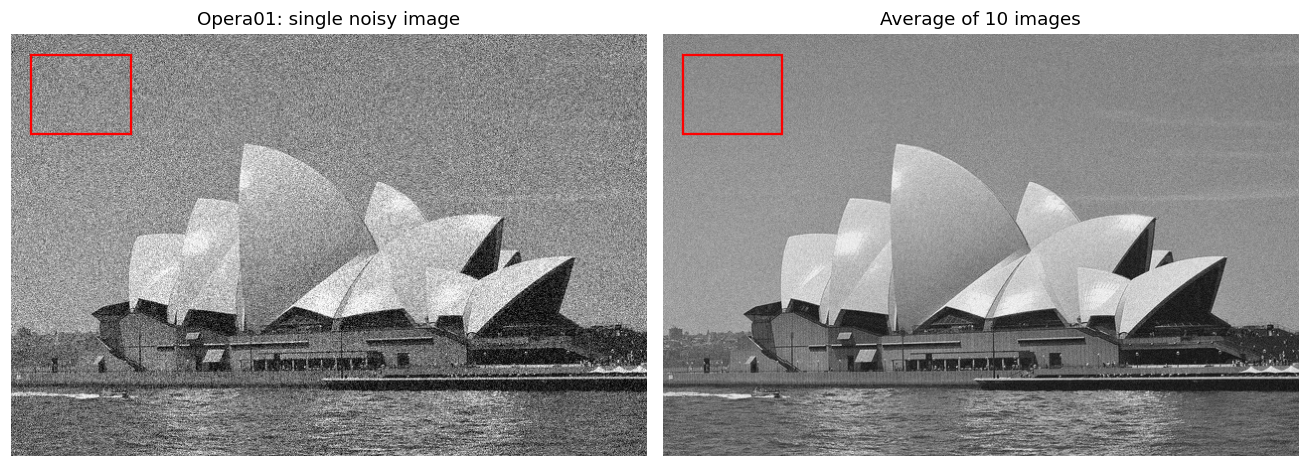

**Measured results:** same sky rectangle in both images,
columns `20:120` and rows `20:100` (zero-based).

| Quantity | Value |
|---|---:|
| Standard deviation in Opera01 | 25.397787 |
| Standard deviation in the average | 8.325364 |
| Ratio (single / average) | 3.050652 |
| Theoretical reduction factor | 3.162278 |


In [2]:
opera = np.stack([load_gray(f"Opera{i:02d}.jpg", IMAGE_DIR)
                  for i in range(1, 11)], axis=0)
average = np.mean(opera, axis=0)

# A structure-free rectangle in the top-left sky; endpoints are exclusive.
x0, x1, y0, y1 = 20, 120, 20, 100
single_roi = opera[0, y0:y1, x0:x1]
average_roi = average[y0:y1, x0:x1]
std_single = np.std(single_roi, ddof=0)
std_average = np.std(average_roi, ddof=0)
ratio = std_single / std_average

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
for ax, img, title in zip(axes, [opera[0], average],
                         ["Opera01: single noisy image", "Average of 10 images"]):
    ax.imshow(img, cmap="gray", vmin=0, vmax=255)
    ax.add_patch(Rectangle((x0, y0), x1-x0, y1-y0,
                           fill=False, edgecolor="red", linewidth=1.5))
    ax.set_title(title)
    ax.axis("off")
plt.tight_layout()
plt.show()

display(Markdown(f"""**Measured results:** same sky rectangle in both images,
columns `{x0}:{x1}` and rows `{y0}:{y1}` (zero-based).

| Quantity | Value |
|---|---:|
| Standard deviation in Opera01 | {std_single:.6f} |
| Standard deviation in the average | {std_average:.6f} |
| Ratio (single / average) | {ratio:.6f} |
| Theoretical reduction factor | {np.sqrt(10):.6f} |
"""))

### Answers

**Theoretical reduction:** Assume $I_k=S+n_k$, where noise has zero mean, equal variance $\sigma^2$, and is independent across images at each pixel. Then $\operatorname{Var}(\bar n)=\sigma^2/N$, so the noise standard deviation becomes $\sigma/\sqrt{N}$. For ten images, it drops by a factor of $\sqrt{10}\approx3.1623$ (to about 31.62% of the original).

**Practical reduction:** The table above gives the measured standard deviations and their ratio, using population standard deviation (`ddof=0`) on the same 100 × 80 sky rectangle. This is an estimate of noise: any residual sky gradient contributes to spatial variance. Finite sampling, JPEG compression, clipping, and departures from independent equal-variance noise can also cause the measured ratio to differ from the theoretical value.

## Task 2 — Derivatives and gradient magnitude

The specified kernels are **Prewitt kernels**. We use the exact matrices from the specification. OpenCV `filter2D` performs correlation, so we flip each kernel by 180° to implement convolution. Reflecting the border keeps the output the same size as the input. Signed floating-point derivatives preserve negative values; the magnitude is computed before any display scaling.

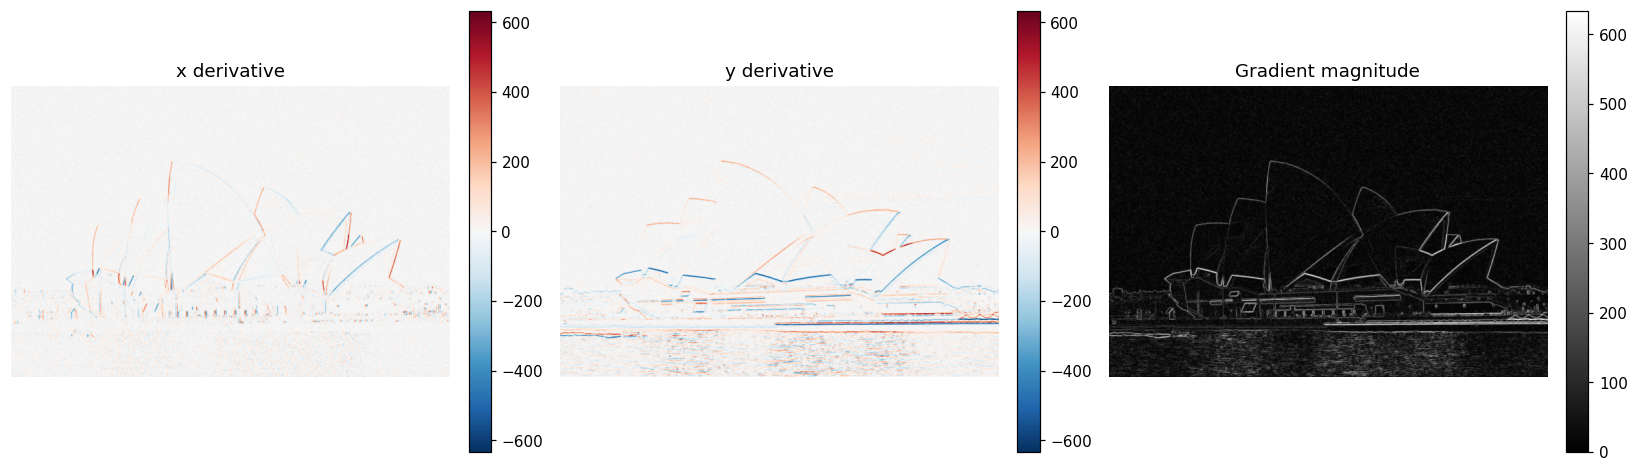

Input and output shape: (425, 640); derivative dtype: float64
dx range: [-587.50, 589.40]
dy range: [-633.50, 595.40]
Magnitude range: [0.00, 633.92]


In [3]:
PX = np.array([[1, 0, -1], [1, 0, -1], [1, 0, -1]], dtype=np.float64)
PY = np.array([[1, 1, 1], [0, 0, 0], [-1, -1, -1]], dtype=np.float64)

def prewitt_gradient(image):
    image = np.asarray(image, dtype=np.float64)
    dx = cv2.filter2D(image, cv2.CV_64F, cv2.flip(PX, -1),
                     borderType=cv2.BORDER_REFLECT_101)
    dy = cv2.filter2D(image, cv2.CV_64F, cv2.flip(PY, -1),
                     borderType=cv2.BORDER_REFLECT_101)
    magnitude = np.hypot(dx, dy)
    return dx, dy, magnitude

dx, dy, magnitude = prewitt_gradient(average)
limit = max(np.max(np.abs(dx)), np.max(np.abs(dy)))
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
for ax, img, title in zip(axes[:2], [dx, dy], ["x derivative", "y derivative"]):
    plot = ax.imshow(img, cmap="RdBu_r", vmin=-limit, vmax=limit)
    ax.set_title(title)
    ax.axis("off")
    fig.colorbar(plot, ax=ax, fraction=0.046, pad=0.04)
plot = axes[2].imshow(magnitude, cmap="gray", vmin=0, vmax=magnitude.max())
axes[2].set_title("Gradient magnitude")
axes[2].axis("off")
fig.colorbar(plot, ax=axes[2], fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()
print(f"Input and output shape: {average.shape}; derivative dtype: {dx.dtype}")
print(f"dx range: [{dx.min():.2f}, {dx.max():.2f}]")
print(f"dy range: [{dy.min():.2f}, {dy.max():.2f}]")
print(f"Magnitude range: [{magnitude.min():.2f}, {magnitude.max():.2f}]")

**Answer:** These are the Prewitt horizontal and vertical derivative kernels. The final image is $\|\nabla I\|=\sqrt{I_x^2+I_y^2}$. Display limits affect only the plots, not the stored derivative or magnitude arrays.

## Task 3 — Unsharp masking

We calculate $L=I*G_\sigma$, $H=I-L$, and $O=I+aH$. The parameters appear at the beginning of the code. The Gaussian kernel size is chosen automatically by OpenCV from the positive sigma. We retain the signed high-frequency mask and unbounded output in floating point, then clip to [0, 255] for display.

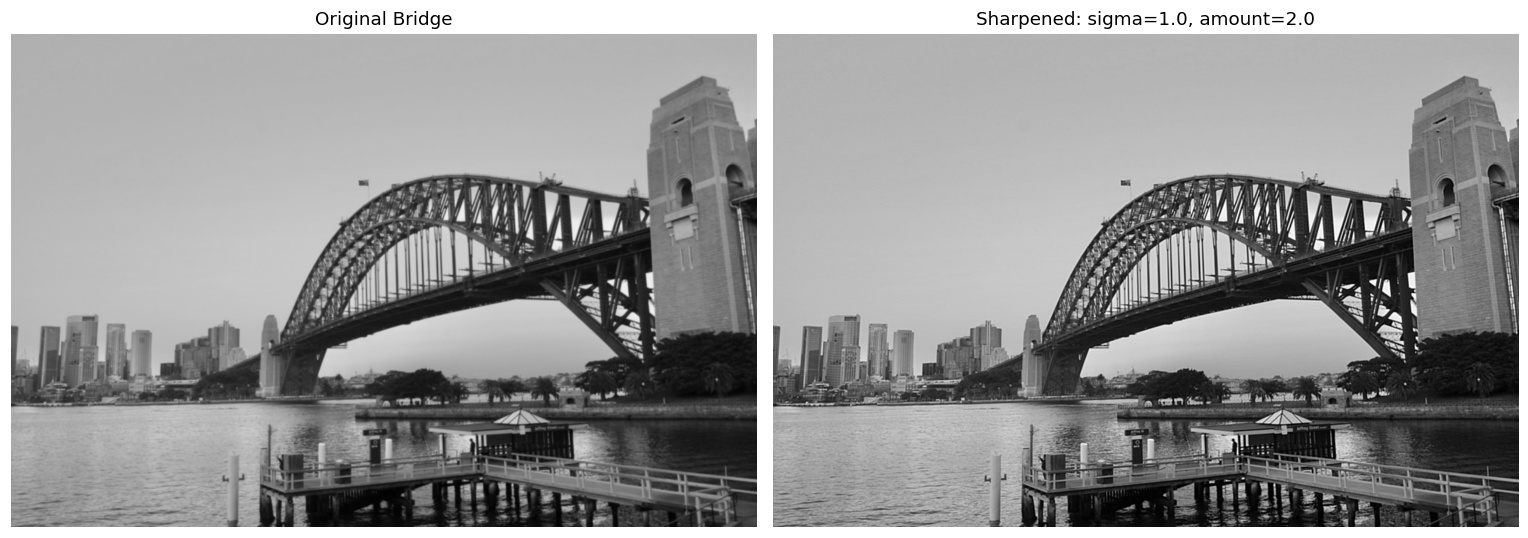

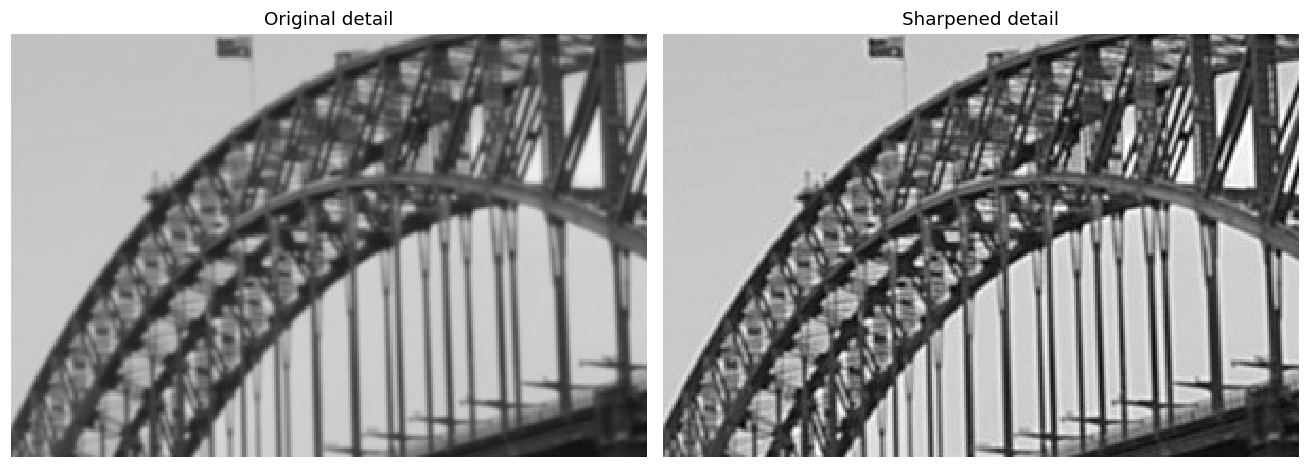

Raw sharpened range: [-19.86, 283.79]
Pixels clipped for display: 0.22%


In [4]:
SIGMA = 1.0  # pixels
AMOUNT = 2.0

def unsharp_mask(image, sigma, amount):
    if sigma <= 0:
        raise ValueError("sigma must be positive")
    image = np.asarray(image, dtype=np.float64)
    blurred = cv2.GaussianBlur(image, (0, 0), sigmaX=sigma, sigmaY=sigma,
                               borderType=cv2.BORDER_REFLECT_101)
    high_frequency = image - blurred
    raw_output = image + amount * high_frequency
    output = np.clip(raw_output, 0, 255)
    return blurred, high_frequency, raw_output, output

bridge = load_gray("Bridge.jpg", IMAGE_DIR)
blurred, high_frequency, raw_output, sharpened = unsharp_mask(bridge, SIGMA, AMOUNT)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, img, title in zip(axes, [bridge, sharpened],
                         ["Original Bridge", f"Sharpened: sigma={SIGMA}, amount={AMOUNT}"]):
    ax.imshow(img, cmap="gray", vmin=0, vmax=255)
    ax.axis("off")
    ax.set_title(title)
plt.tight_layout()
plt.show()

# Identical detail crop and display scale make the sharpening easier to assess.
detail = np.s_[250:450, 500:800]
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
for ax, img, title in zip(axes, [bridge[detail], sharpened[detail]],
                         ["Original detail", "Sharpened detail"]):
    ax.imshow(img, cmap="gray", vmin=0, vmax=255, interpolation="nearest")
    ax.axis("off")
    ax.set_title(title)
plt.tight_layout()
plt.show()
print(f"Raw sharpened range: [{raw_output.min():.2f}, {raw_output.max():.2f}]")
print(f"Pixels clipped for display: {np.mean((raw_output < 0) | (raw_output > 255)):.2%}")

The sharpened output increases local contrast around bridge details. The high-frequency term can be negative or positive, and the raw output can exceed the 8-bit range; clipping is applied only after the complete calculation.

## Implementation checks

The checks below verify dimensions, finite outputs, the convolution sign and magnitude on synthetic ramps, zero gradients on a constant image, and the unsharp masking identities.

In [5]:
assert opera.shape[0] == 10
assert average.shape == dx.shape == dy.shape == magnitude.shape
assert all(np.isfinite(img).all() for img in (average, dx, dy, magnitude, sharpened))
assert np.all(magnitude >= 0)
constant = np.full((9, 9), 100.0)
cx, cy, cm = prewitt_gradient(constant)
assert np.allclose(cm, 0)
horizontal_ramp = np.tile(np.arange(9, dtype=float), (9, 1))
rx, ry, rm = prewitt_gradient(horizontal_ramp)
assert np.allclose(rx[1:-1, 1:-1], 6)
assert np.allclose(ry[1:-1, 1:-1], 0)
rx, ry, rm = prewitt_gradient(horizontal_ramp.T)
assert np.allclose(rx[1:-1, 1:-1], 0)
assert np.allclose(ry[1:-1, 1:-1], 6)
assert np.allclose(unsharp_mask(constant, SIGMA, AMOUNT)[3], constant)
assert np.allclose(unsharp_mask(bridge, SIGMA, 0)[3], bridge)
assert np.allclose(raw_output, bridge + AMOUNT * (bridge - blurred))
assert sharpened.shape == bridge.shape
assert sharpened.min() >= 0 and sharpened.max() <= 255
print("All implementation checks passed.")

All implementation checks passed.
